In [56]:
import os
from os.path import join as pjoin

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import stackstac
import planetary_computer as pc
import dask.diagnostics

from affine import Affine
from rasterio import features
from pystac import ItemCollection

In [61]:
# inputs             
OUT_DIR = Path("data/outputs_ndvi_2013")
OUT_DIR.mkdir(exist_ok=True)

TARGET_EPSG = 27700
TARGET_RES = 30  

DATE_START = "2013-01-01T00:00:00Z"
DATE_END = "2013-12-31T23:59:59Z"


In [62]:
# read ward poly 
wards = gpd.read_file("data/ward_poly.gpkg")

wards = wards[["New.ward.code", "geometry"]].copy()
wards = wards.to_crs(27700)   # British National Grid
wards["zone_id"] = np.arange(1, len(wards) + 1, dtype=np.int32)

print("Number of wards:", len(wards))
print("CRS:", wards.crs)
print(wards.head())


Number of wards: 625
CRS: EPSG:27700
  New.ward.code                                           geometry  zone_id
0     E05000026  MULTIPOLYGON (((543595.5 184832.8, 543601.7 18...        1
1     E05000027  MULTIPOLYGON (((547932.4 184916.6, 547944.8 18...        2
2     E05000028  MULTIPOLYGON (((546209.4 185783.6, 546219.3 18...        3
3     E05000029  MULTIPOLYGON (((547715.2 187914.2, 547712.5 18...        4
4     E05000030  MULTIPOLYGON (((549991.5 184928.5, 549988.9 18...        5


In [63]:
# Search against the Planetary Computer STAC API
catalog = Client.open(
  "https://planetarycomputer.microsoft.com/api/stac/v1"
)

# Define your area of interest
aoi = {
  "type": "Polygon",
  "coordinates": [
    [
      [-0.440323880880527, 51.35790631689915],
      [0.30466742119699575, 51.35790631689915],
      [0.30466742119699575, 51.62048579935282],
      [-0.440323880880527, 51.62048579935282],
      [-0.440323880880527, 51.35790631689915]
    ]
  ]
}

# Define your temporal range
daterange = {"interval": [DATE_START, DATE_END]}

# Define your search with CQL2 syntax
search = catalog.search(filter_lang="cql2-json", filter={
  "op": "and",
  "args": [
    {"op": "s_intersects", "args": [{"property": "geometry"}, aoi]},
    {"op": "anyinteracts", "args": [{"property": "datetime"}, daterange]},
    {"op": "=", "args": [{"property": "collection"}, "landsat-c2-l2"]},
    {"op": "<=", "args": [{"property": "eo:cloud_cover"}, 20]},
    {"op": "in", "args": [{"property": "platform"}, ["landsat-8", "landsat-9","landsat-7"]]}
  ]
})

items = search.item_collection()
if len(items) == 0:
    raise ValueError("No Landsat scenes found for the AOI and date range.")

print(f"Found {len(items)} scenes.")

Found 4 scenes.


In [64]:
# stack the Landsat scenes
items_ic = ItemCollection(items)

ds = stackstac.stack(
    pc.sign(items_ic),
    assets=["red", "nir08"],
    epsg=27700,
    resolution=30
)

print("sizes:", ds.sizes)
print("time slices:", ds.sizes["time"])
print("bands:", ds.sizes["band"])
print("data size (GB):", ds.nbytes / 1e9)

sizes: Frozen({'time': 4, 'band': 2, 'y': 8716, 'x': 11942})
time slices: 4
bands: 2
data size (GB): 6.661534208


In [65]:
# crop to the London ward extent
xmin, ymin, xmax, ymax = wards.total_bounds

london = ds.loc[:, :, ymax:ymin, xmin:xmax]
london

<xarray.DataArray 'stackstac-90c2fd0decbdc8e88b942109312d0dc0' (time: 4,
                                                                band: 2,
                                                                y: 1502, x: 1946)> Size: 187MB
dask.array<getitem, shape=(4, 2, 1502, 1946), dtype=float64, chunksize=(1, 1, 777, 1024), chunktype=numpy.ndarray>
Coordinates: (12/27)
  * time                         (time) datetime64[ns] 32B 2013-04-20T10:48:2...
    id                           (time) <U31 496B 'LE07_L2SP_201024_20130420_...
    proj:code                    (time) <U10 160B 'EPSG:32631' ... 'EPSG:32631'
    eo:cloud_cover               (time) float64 32B 1.0 14.69 2.29 14.98
    view:sun_azimuth             (time) float64 32B 154.6 151.5 149.1 149.5
    view:sun_elevation           (time) float64 32B 47.61 58.59 57.85 56.54
    ...                           ...
    view:off_nadir               int32 4B 0
    landsat:collection_number    <U2 8B '02'
    landsat:wrs_type             <U1 4B '2'
    landsat:correction           <U4 16B 'L2SP'
    raster:bands                 object 8B {'scale': 2.75e-05, 'nodata': 0, '...
    epsg                         int32 4B 27700
Attributes:
    spec:        RasterSpec(epsg=27700, bounds=(345000, 71280, 703260, 332760...
    crs:         epsg:27700
    transform:   | 30.00, 0.00, 345000.00|\n| 0.00,-30.00, 332760.00|\n| 0.00...
    resolution:  30

In [66]:
# compute NDVI
red = london.sel(band="red")
nir = london.sel(band="nir08")

ndvi = (nir - red) / (nir + red)
ndvi

<xarray.DataArray 'stackstac-90c2fd0decbdc8e88b942109312d0dc0' (time: 4,
                                                                y: 1502, x: 1946)> Size: 94MB
dask.array<truediv, shape=(4, 1502, 1946), dtype=float64, chunksize=(1, 777, 1024), chunktype=numpy.ndarray>
Coordinates: (12/25)
  * time                         (time) datetime64[ns] 32B 2013-04-20T10:48:2...
    id                           (time) <U31 496B 'LE07_L2SP_201024_20130420_...
    proj:code                    (time) <U10 160B 'EPSG:32631' ... 'EPSG:32631'
    eo:cloud_cover               (time) float64 32B 1.0 14.69 2.29 14.98
    view:sun_azimuth             (time) float64 32B 154.6 151.5 149.1 149.5
    view:sun_elevation           (time) float64 32B 47.61 58.59 57.85 56.54
    ...                           ...
    view:off_nadir               int32 4B 0
    landsat:collection_number    <U2 8B '02'
    landsat:wrs_type             <U1 4B '2'
    landsat:correction           <U4 16B 'L2SP'
    raster:bands                 object 8B {'scale': 2.75e-05, 'nodata': 0, '...
    epsg                         int32 4B 27700
Attributes:
    spec:        RasterSpec(epsg=27700, bounds=(345000, 71280, 703260, 332760...
    crs:         epsg:27700
    transform:   | 30.00, 0.00, 345000.00|\n| 0.00,-30.00, 332760.00|\n| 0.00...
    resolution:  30

In [67]:
# create the monthly max NDVI composite
monthly = ndvi.resample(time="MS").max("time", keep_attrs=True)

print(monthly)

<xarray.DataArray 'stackstac-90c2fd0decbdc8e88b942109312d0dc0' (time: 4,
                                                                y: 1502, x: 1946)> Size: 94MB
dask.array<where, shape=(4, 1502, 1946), dtype=float64, chunksize=(1, 777, 1024), chunktype=numpy.ndarray>
Coordinates: (12/13)
  * time                         (time) datetime64[ns] 32B 2013-04-01 ... 201...
  * y                            (y) float64 12kB 2.009e+05 ... 1.559e+05
  * x                            (x) float64 16kB 5.036e+05 ... 5.619e+05
    gsd                          int32 4B 30
    landsat:collection_category  <U2 8B 'T1'
    landsat:wrs_row              <U3 12B '024'
    ...                           ...
    view:off_nadir               int32 4B 0
    landsat:collection_number    <U2 8B '02'
    landsat:wrs_type             <U1 4B '2'
    landsat:correction           <U4 16B 'L2SP'
    raster:bands                 object 8B {'scale': 2.75e-05, 'nodata': 0, '...
    epsg                         int32 

In [68]:
# compute the monthly time series
with dask.diagnostics.ProgressBar():
    ts = monthly.compute()

ts

[########################################] | 100% Completed | 22.63 s


<xarray.DataArray 'stackstac-90c2fd0decbdc8e88b942109312d0dc0' (time: 4,
                                                                y: 1502, x: 1946)> Size: 94MB
array([[[0.57228928, 0.59373494, 0.57512131, ..., 0.62998978,
         0.65097394, 0.62652734],
        [0.57948856, 0.57512131, 0.68608676, ..., 0.60986929,
         0.5878165 , 0.4753728 ],
        [       nan, 0.60530296, 0.62539564, ..., 0.66026811,
         0.51727284, 0.43621735],
        ...,
        [0.25008179, 0.42704285, 0.4794071 , ..., 0.50499824,
         0.38479631, 0.36970432],
        [0.39160867, 0.45073851, 0.52771564, ..., 0.43311408,
         0.38915404, 0.38915404],
        [0.50329694, 0.45492388, 0.44611769, ..., 0.39648109,
         0.39648109, 0.38910393]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.8947899 , 0.87894268, 0.7744664 , ...,        nan,
                nan,        nan],
        [0.84929193, 0.76980661, 0.64456054, ...,        nan,
                nan,        nan],
        [0.64211123, 0.59096427, 0.55041392, ...,        nan,
                nan,        nan]],

       [[0.84880469, 0.80683804, 0.78213701, ..., 0.72354804,
         0.71655941, 0.72416893],
        [0.87133583, 0.86028421, 0.8325504 , ..., 0.75247164,
         0.57684532, 0.46919046],
        [0.81323156, 0.8541467 , 0.85127157, ..., 0.68411373,
         0.45451644, 0.42908648],
        ...,
        [0.80506807, 0.74887557, 0.72387503, ..., 0.6489162 ,
         0.61138211, 0.63952147],
        [0.75280856, 0.72638589, 0.55147279, ..., 0.58382249,
         0.63998118, 0.68574676],
        [0.64531468, 0.51376617, 0.48521506, ..., 0.59513989,
         0.65150583, 0.67979781]]])
Coordinates: (12/13)
  * time                         (time) datetime64[ns] 32B 2013-04-01 ... 201...
  * y                            (y) float64 12kB 2.009e+05 ... 1.559e+05
  * x                            (x) float64 16kB 5.036e+05 ... 5.619e+05
    gsd                          int32 4B 30
    landsat:collection_category  <U2 8B 'T1'
    landsat:wrs_row              <U3 12B '024'
    ...                           ...
    view:off_nadir               int32 4B 0
    landsat:collection_number    <U2 8B '02'
    landsat:wrs_type             <U1 4B '2'
    landsat:correction           <U4 16B 'L2SP'
    raster:bands                 object 8B {'scale': 2.75e-05, 'nodata': 0, '...
    epsg                         int32 4B 27700
Attributes:
    spec:        RasterSpec(epsg=27700, bounds=(345000, 71280, 703260, 332760...
    crs:         epsg:27700
    transform:   | 30.00, 0.00, 345000.00|\n| 0.00,-30.00, 332760.00|\n| 0.00...
    resolution:  30

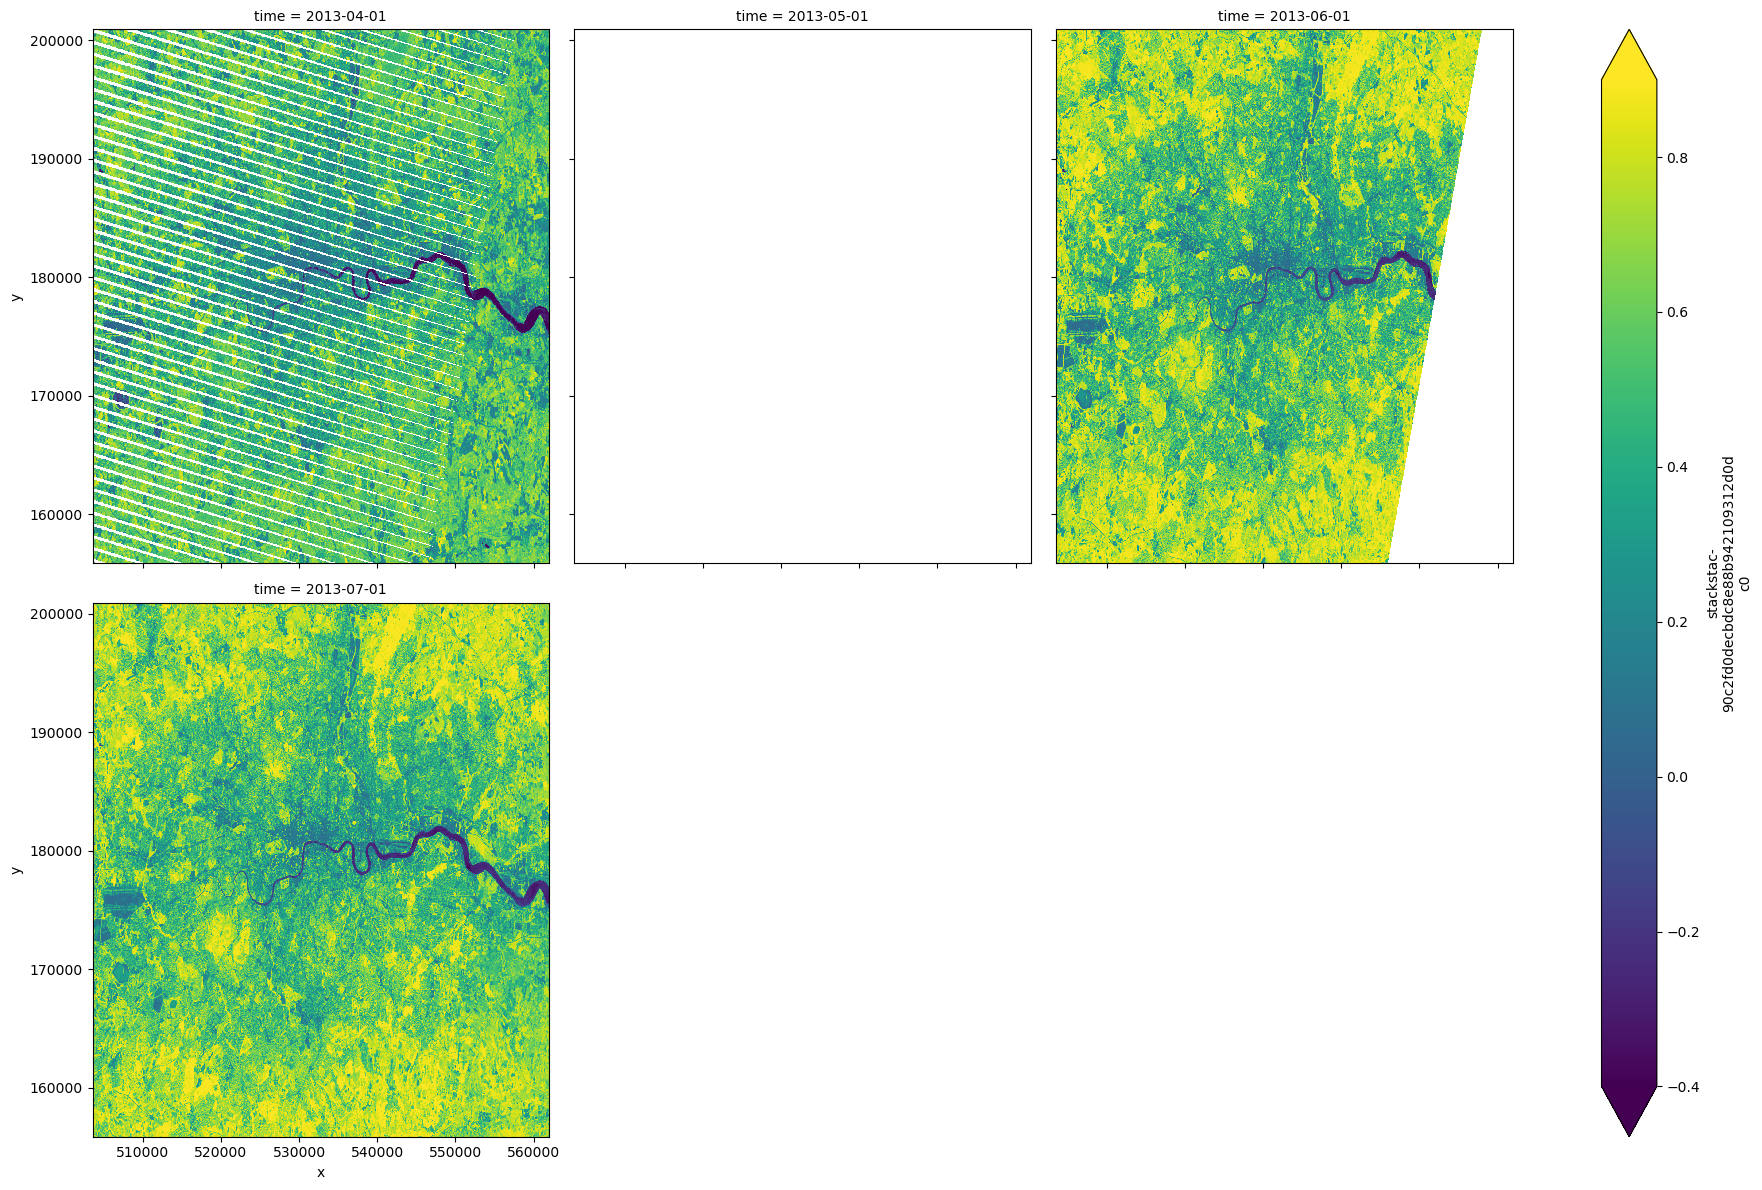

In [69]:
ts.plot.imshow(col="time", col_wrap=3, size=6, vmin=-0.4, vmax=0.9)

In [76]:
# write the monthly NDVI stack to disk
os.makedirs(OUT_DIR, exist_ok=True)

tss = ts.copy()
tss = tss.rename("ndvi")

tss.rio.write_crs("EPSG:27700", inplace=True)
tss.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)

tss.rio.to_raster(pjoin(OUT_DIR, "tss_ndvi_2013.tif"), compress="LZW")

print("Saved:", pjoin(OUT_DIR, "tss_ndvi_2013.tif"))

Saved: data\outputs_ndvi_2013\tss_ndvi_2013.tif


In [77]:
# rasterize the wards to the NDVI grid
x = tss.x.values
y = tss.y.values

dx = float(abs(x[1] - x[0]))
dy = float(abs(y[1] - y[0]))

transform = Affine.translation(x.min() - dx / 2, y.max() + dy / 2) * Affine.scale(dx, -dy)

zone_raster = features.rasterize(
    shapes=((geom, zid) for geom, zid in zip(wards.geometry, wards["zone_id"])),
    out_shape=(len(y), len(x)),
    transform=transform,
    fill=0,
    dtype="int32",
    all_touched=False
)

print(zone_raster.shape)

(1502, 1946)


In [78]:
# calculate the mean NDVI for each ward for each month
monthly_records = []

for t in tss.time.values:
    arr = tss.sel(time=t).values

    valid = np.isfinite(arr) & (zone_raster > 0)

    zones = zone_raster[valid]
    vals = arr[valid]

    sum_by_zone = np.bincount(zones, weights=vals, minlength=len(wards) + 1)
    cnt_by_zone = np.bincount(zones, minlength=len(wards) + 1)

    mean_by_zone = np.full(len(wards) + 1, np.nan, dtype="float64")
    ok = cnt_by_zone > 0
    mean_by_zone[ok] = sum_by_zone[ok] / cnt_by_zone[ok]

    df_month = wards[["New.ward.code", "zone_id"]].copy()
    df_month["month"] = pd.Timestamp(t).strftime("%Y-%m")
    df_month["mean_ndvi"] = mean_by_zone[df_month["zone_id"].values]

    monthly_records.append(df_month[["New.ward.code", "month", "mean_ndvi"]])

ward_monthly = pd.concat(monthly_records, ignore_index=True)

print(ward_monthly.head())
print(ward_monthly.shape)

  New.ward.code    month  mean_ndvi
0     E05000026  2013-04   0.291306
1     E05000027  2013-04   0.456588
2     E05000028  2013-04   0.404488
3     E05000029  2013-04   0.461945
4     E05000030  2013-04   0.485948
(2500, 3)


In [79]:
# calculate the 2013 annual average NDVI per ward
ward_annual = (
    ward_monthly.groupby("New.ward.code", as_index=False)
    .agg(
        annual_ndvi_2013=("mean_ndvi", "mean"),
        months_with_data=("mean_ndvi", lambda s: s.notna().sum())
    )
)

print(ward_annual.head())

  New.ward.code  annual_ndvi_2013  months_with_data
0     E05000026          0.330213                 3
1     E05000027          0.454086                 3
2     E05000028          0.414563                 3
3     E05000029          0.524576                 3
4     E05000030          0.523915                 3


In [80]:
# save the final outputs
ward_monthly.to_csv(pjoin(OUT_DIR, "ward_ndvi_monthly_2013.csv"), index=False)
ward_annual.to_csv(pjoin(OUT_DIR, "ward_ndvi_annual_2013.csv"), index=False)

wards_out = wards.merge(ward_annual, on="New.ward.code", how="left")
wards_out.to_file(pjoin(OUT_DIR, "ward_ndvi_annual_2013.gpkg"), driver="GPKG")

print("Saved monthly:", pjoin(OUT_DIR, "ward_ndvi_monthly_2013.csv"))
print("Saved annual:", pjoin(OUT_DIR, "ward_ndvi_annual_2013.csv"))
print("Saved gpkg:", pjoin(OUT_DIR, "ward_ndvi_annual_2013.gpkg"))

Saved monthly: data\outputs_ndvi_2013\ward_ndvi_monthly_2013.csv
Saved annual: data\outputs_ndvi_2013\ward_ndvi_annual_2013.csv
Saved gpkg: data\outputs_ndvi_2013\ward_ndvi_annual_2013.gpkg


In [81]:
print(ward_annual["annual_ndvi_2013"].describe())
print("Min:", ward_annual["annual_ndvi_2013"].min())
print("Max:", ward_annual["annual_ndvi_2013"].max())
print("Wards with data:", (ward_annual["months_with_data"] > 0).sum())

count    625.000000
mean       0.450227
std        0.113270
min        0.094094
25%        0.373771
50%        0.459820
75%        0.531309
max        0.712138
Name: annual_ndvi_2013, dtype: float64
Min: 0.0940935345427647
Max: 0.7121382024777644
Wards with data: 625
